# Moving Average Crossover Analysis
(markdown header)

## 1. Setup and Parameters
(markdown header)

In [1]:
import yfinance as yf

# --- Parameters ---
TICKER = "NOW"
LOOKBACK_PERIOD = "2y"
SHORT_MA = 50
LONG_MA = 200

## 2. Load Price Data
(markdown header)

In [2]:
ticker = yf.Ticker(TICKER)
data = ticker.history(period=LOOKBACK_PERIOD)
print(f"Loaded {len(data)} rows from {data.index.min().date()} to {data.index.max().date()}")
data.head()

Loaded 501 rows from 2024-04-18 to 2026-04-17


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-04-18 00:00:00-04:00,147.380005,147.977997,145.470001,146.272003,3943500,0.0,0.0
2024-04-19 00:00:00-04:00,145.000000,145.205994,141.705994,142.781998,7703000,0.0,0.0
2024-04-22 00:00:00-04:00,144.649994,144.998001,142.123993,144.389999,7321000,0.0,0.0
2024-04-23 00:00:00-04:00,145.440002,148.733994,145.440002,148.190002,5824500,0.0,0.0
2024-04-24 00:00:00-04:00,150.794006,151.449997,147.826004,149.257996,8528000,0.0,0.0


## 3. Moving Averages
(markdown header)

In [3]:
data["MA_short"] = data["Close"].rolling(window=SHORT_MA).mean()
data["MA_long"] = data["Close"].rolling(window=LONG_MA).mean()
data[["Close", "MA_short", "MA_long"]].tail()

,Close,MA_short,MA_long
Date,,,
2026-04-13 00:00:00-04:00,89.059998,107.2240,157.44926
2026-04-14 00:00:00-04:00,87.790001,106.6396,156.87677
2026-04-15 00:00:00-04:00,94.190002,106.1634,156.32530
2026-04-16 00:00:00-04:00,96.440002,105.8968,155.77942
2026-04-17 00:00:00-04:00,96.660004,105.6086,155.25083


## 4. Plot Graph
(markdown header)

<Axes: title={'center': 'NOW Price and Moving Averages'}, xlabel='Date'>

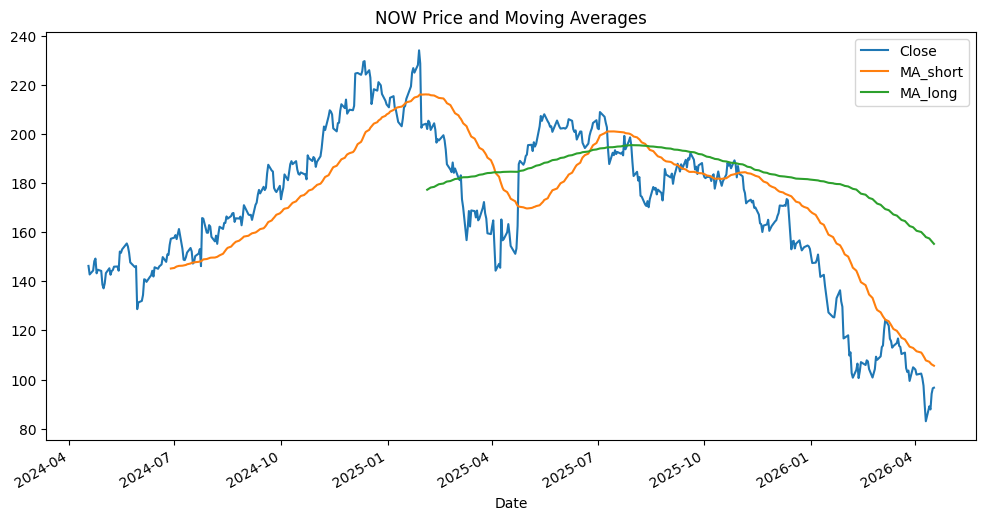

In [4]:
data[["Close", "MA_short", "MA_long"]].plot(figsize=(12, 6), title=f"{TICKER} Price and Moving Averages")

## 5. Calc Golden Cross
(markdown header)

In [5]:
today_above = data["MA_short"] > data["MA_long"]
yesterday_below = data["MA_short"].shift(1) <= data["MA_long"].shift(1)

golden_crosses = data[today_above & yesterday_below]

print(f"Found {len(golden_crosses)} golden cross(es) for {TICKER}:")
golden_crosses[["Close", "MA_short", "MA_long"]]

Found 1 golden cross(es) for NOW:


,Close,MA_short,MA_long
Date,,,
2025-06-25 00:00:00-04:00,201.031998,193.736759,193.17898
